# Hopper locomotion — algorithm bake-off

Closed-loop planar hopper (3 actuators): track target forward velocity at target height while staying upright. Shares the walker's torso sensor layout, so it reuses `walker_metrics` (aliased as `hopper_metrics`).

In [11]:
# Always pick up the latest code in analytic_mppi/ (incl. experimental.py)
# without restarting the kernel — edit a .py, re-run a cell, done.
%load_ext autoreload
%autoreload 2

import numpy as np
from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.eval import (
    Config, run_study, plot_study, summarize, render_video,
    hopper_metrics, hopper_panels, hopper_metrics, hopper_panels
)
# Controllers are imported straight from the package (autoreloaded):
from analytic_mppi.controllers import MPPIv2, MppiCma, CEM, DIAL, PredictiveSampling
from analytic_mppi.controllers.experimental import UniformGD, GaussianGD, RankCMA, FplValueCMA

TASK = "hopper"
task = make_task(TASK)
DT = MujocoBackend(task.model_path).dt
print(f"task={TASK}  nq={task.nq} nv={task.nv} nu={task.nu} dt={DT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
task=hopper  nq=6 nv=6 nu=3 dt=0.02


## Experiment configuration

Each `Config` is one row: a label, the controller **class** (imported above), the cost mode, and its algo kwargs. Shared sampler settings apply to every row.

In [12]:
SHARED = dict(num_samples=128, plan_horizon=1.0, num_knots=6)

CONFIGS = [
    Config("mppi  (normal)",          MPPIv2,       "normal",         dict(noise_level=0.3, temperature=0.05)),
    Config("mppi_cma  (normal)",      MppiCma,      "normal",         dict(initial_noise_level=0.5, temperature=0.05, minimum_noise_level=0.1)),
    Config("mppi  (fpl)",             MPPIv2,       "fpl_discounted", dict(noise_level=0.3, temperature=0.05)),
    Config("mppi_cma  (fpl)",         MppiCma,      "fpl_discounted", dict(initial_noise_level=0.5, temperature=0.05, minimum_noise_level=0.1)),
    Config("uniform_gd  (fpl)",       UniformGD,    "fpl_discounted", dict(noise_level=0.5, n_gd_iter=5)),
    Config("gaussian_gd  (fpl)",      GaussianGD,   "fpl_discounted", dict(noise_level=0.3, n_gd_iter=5)),
    Config("rank_cma  (fpl)",         RankCMA,      "fpl_discounted", dict(sigma_init=0.5, n_gd_iter=5)),
    Config("fpl_value_cma  (fpl)",    FplValueCMA,  "fpl_discounted", dict(sigma_init=0.5, beta=10.0, n_gd_iter=5)),
    # --- cost-GD variants: SAME base sampler + BPTT cost-gradient refinement of the
    #     top-mu rollouts each step. cost_gd=dict(...) wraps any row. Requires nq == nv,
    #     so pendulum / walker / hopper only (g1_standup / cube raise NotImplementedError).
    Config("mppi_costgd  (fpl)",        MPPIv2,     "fpl_discounted", dict(noise_level=0.3, temperature=0.05), cost_gd=dict(gd_iterations=2, gd_lr=10.0)),
    Config("gaussian_gd_costgd  (fpl)", GaussianGD, "fpl_discounted", dict(noise_level=0.3, n_gd_iter=5),       cost_gd=dict(gd_iterations=2, gd_lr=10.0)),
]

## Run the closed-loop study

Fresh MuJoCo sim per (config, episode); mean ± 1 std bands across episodes.

running mppi  (normal)                          ... done
running mppi_cma  (normal)                      ... done
running mppi  (fpl)                             ... done
running mppi_cma  (fpl)                         ... done
running uniform_gd  (fpl)                       ... done
running gaussian_gd  (fpl)                      ... done
running rank_cma  (fpl)                         ... done
running fpl_value_cma  (fpl)                    ... done
running mppi_costgd  (fpl)                      ... done
running gaussian_gd_costgd  (fpl)               ... done
config                                      height_err       vel_err       upright         u_mag
mppi  (normal)                                  0.4048        0.6534        0.9082        0.5224
mppi_cma  (normal)                              0.4802        0.6698        0.9024        0.5022
mppi  (fpl)                                     0.3702        0.5732        0.9050        0.4673
mppi_cma  (fpl)                           

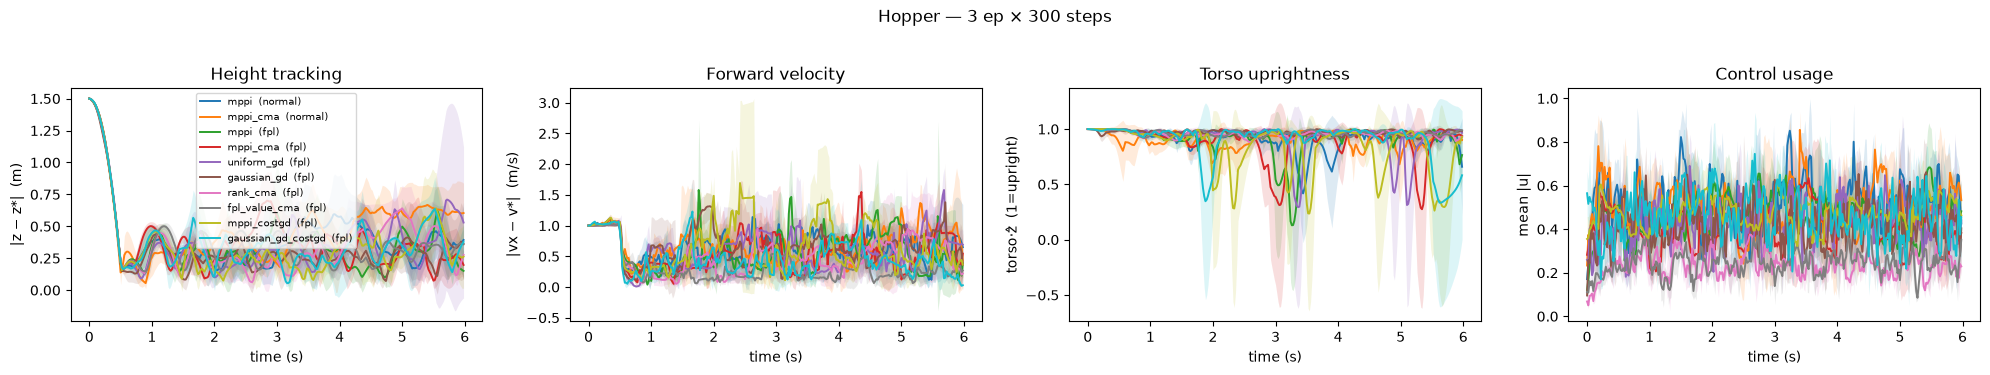

In [13]:
STEPS = 300
N_EPISODES = 3

study = run_study(TASK, CONFIGS, steps=STEPS, n_episodes=N_EPISODES,
                  **SHARED)

plot_study(study, lambda r: hopper_metrics(r, task), hopper_panels(), dt=DT,
           title=f"Hopper — {N_EPISODES} ep × {STEPS} steps")
summarize(study, lambda r: hopper_metrics(r, task), ["height_err", "vel_err", "upright", "u_mag"])

## (optional) Render a video of one config

Set `RUN_VIDEO = True` to render an mp4 of a single config and embed it.

In [14]:
RUN_VIDEO = False
if RUN_VIDEO:
    from IPython.display import Video, display
    res = render_video(TASK, RankCMA, steps=300, out_path="/tmp/hopper_rank_cma.mp4",
                       cost_mode="fpl_discounted", sigma_init=0.5, n_gd_iter=5, **SHARED)
    print(f"plan {res['plan_ms']:.1f} ms/step")
    display(Video(str(res["path"]), embed=True, width=360))
else:
    print("set RUN_VIDEO = True to render")

set RUN_VIDEO = True to render


## Hopper: vanilla MPPI vs FPL vs FPL + soft-min-over-time

Three closed-loop runs from a settled stand (`init_hopper_stand`, `track` camera), autoplay/loop. Captions show forward distance, mean speed, and **min uprightness** over the run (below 0.6 ⇒ the torso toppled = fell):

- **normal MPPI** — vanilla MPPI on the legacy hand-tuned quadratic cost. Safe but slow (its 50× orientation penalty is a strong don't-fall term).
- **fpl (p=−2) time-avg** — FPL weakest-link conjunction with the *original* time aggregation. A trajectory's value is a time **average**, which launders away a single catastrophic step — so FPL chases speed and sometimes topples (8-seed fall rate **4/8**).
- **fpl (p=−2) + soft-min time** — the *same* FPL, but a trajectory's value = its **worst moment** (`fpl_time_p=−2`, a soft-min over the time axis). Now a fall is actually penalized → 8-seed fall rate drops to **1/8** at a small speed cost.

> This is one seed (`SEED_CMP`), and FPL's fall is seed-dependent (~half the seeds at p=−2 time-avg). If the middle clip doesn't topple on the chosen seed, bump `SEED_CMP` to find one where it does — the point is that soft-min removes those falls.

In [15]:
from analytic_mppi.eval import init_hopper_stand
import base64
from IPython.display import HTML, display

STEPS_CMP  = 200          # 4.0 s at dt=0.02
SEED_CMP   = 3            # a seed where the contrast is clean (see note below); try others too
SHARED_CMP = dict(num_samples=256, plan_horizon=0.6, num_knots=4, spline_type="zero", noise_level=0.3)
print(f"target_velocity={task.target_velocity}")

# (label, cost_mode, fpl_p, temperature, fpl_time_p)
#   normal  : vanilla MPPI on the legacy quadratic cost (own temperature).
#   fpl     : FPL conjunction, p=-2, time-AVERAGE aggregation (the original — averages
#             away catastrophic moments, so it chases speed and sometimes falls).
#   fpl+smin: same p=-2 but SOFT-MIN over time (value = worst moment), so a fall is
#             actually penalized. Cut the 8-seed fall rate 4/8 -> 1/8.
RUNS = [
    ("normal MPPI (quadratic cost)", "normal",   None, 1.0, None),
    ("fpl (p=-2)  time-avg",         "fpl_cost", -2.0, 0.2, None),
    ("fpl (p=-2) + soft-min time",   "fpl_cost", -2.0, 0.2, -2.0),
]

def _render(tag, cost_mode, fpl_p, temperature, fpl_time_p):
    kw = dict(cost_mode=cost_mode, temperature=temperature)
    if fpl_p is not None:      kw["fpl_p"] = fpl_p
    if fpl_time_p is not None: kw["fpl_time_p"] = fpl_time_p
    return render_video(TASK, MPPIv2, steps=STEPS_CMP, out_path=f"/tmp/hopper_{tag}.mp4",
                        init_fn=init_hopper_stand, camera="track", seed=SEED_CMP,
                        **SHARED_CMP, **kw)

def _stats(res):
    qpos = task.qpos_of(res["states"])
    qx = qpos[..., 0]                    # torso forward position
    vx = task.qvel_of(res["states"])[..., 0]
    upright = np.cos(qpos[..., 2])       # rooty = torso pitch; cos(rooty)=zaxis_z (1=upright)
    fell = upright.min() < 0.6           # same threshold as the study's fall detector
    return float(qx[-1] - qx[0]), float(vx.mean()), float(upright.min()), bool(fell)

def _vid(path, label, width=300):
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return (f'<figure style="display:inline-block;margin:6px;text-align:center;vertical-align:top">'
            f'<figcaption style="font-family:monospace;font-size:11px">{label}</figcaption>'
            f'<video width="{width}" controls autoplay loop muted>'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video></figure>')

html = ""
for i, (label, cost_mode, fpl_p, temperature, fpl_time_p) in enumerate(RUNS):
    res = _render(f"cmp{i}", cost_mode, fpl_p, temperature, fpl_time_p)
    d, v, minup, fell = _stats(res)
    flag = "  FELL" if fell else ""
    print(f"{label:32s} fwd={d:5.2f} m  mean_vx={v:5.2f}  min_upright={minup:.2f}{flag}  ({res['plan_ms']:.0f} ms/step)")
    cap = f"{label}<br>fwd {d:.2f} m, vx {v:.2f}, min-up {minup:.2f}{' — FELL' if fell else ''}"
    html += _vid(res["path"], cap)
display(HTML(html))

target_velocity=1.0
normal MPPI (quadratic cost)     fwd= 2.72 m  mean_vx= 0.68  min_upright=0.69  (3 ms/step)
fpl (p=-2)  time-avg             fwd= 2.68 m  mean_vx= 0.67  min_upright=-0.99  FELL  (3 ms/step)
fpl (p=-2) + soft-min time       fwd= 3.79 m  mean_vx= 0.94  min_upright=0.88  (4 ms/step)
